# Meme Kanseri Hasta Durumu Sınıflandırma | Breast Cancer Patient Status Classification

**Problem Type:** Binary Classification | **Dataset:** BRCA.csv — 341 patients, 16 clinical features  
**Target:** `patient_status` (Alive / Dead) | **Train/Test Split:** 80/20 (stratified)

> **Objective:** Predict survival status of breast cancer patients using clinical and molecular biomarker data, enabling early risk stratification to support oncology decision-making.

## Dataset Overview
| Attribute | Detail |
|-----------|--------|
| Records | 341 patients (334 valid after missing-row removal) |
| Numeric Features | Age, Protein1, Protein2, Protein3, Protein4 |
| Categorical Features | Gender, Tumour Stage, Histology, ER/PR/HER2 status, Surgery type |
| Class Balance | ~80% Alive, ~20% Dead (imbalanced) |

## Approach & Results
| Model | Accuracy | Notes |
|-------|----------|-------|
| Logistic Regression | 0.8000 | Interpretable baseline |
| Random Forest | 0.7846 | Ensemble method |
| **XGBoost (Best ML)** | **0.8154** | Gradient boosting winner |
| Neural Network (DL) | Dense + sigmoid | Binary cross-entropy, EarlyStopping (patience=10) |

## Pipeline Steps
`Data Loading` → `EDA` → `Visualization` → `Missing Value Analysis` → `Feature Engineering` → `Outlier Clipping (10–90%)` → `Train-Test Split` → `Preprocessing Pipeline` → `ML Comparison` → `Confusion Matrix + ROC-AUC` → `DL Training` → `ML vs DL Comparison` → `Model Saving`

In [ ]:
# Temel Kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import missingno as msno
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import joblib

## 📊 1. Veri Yükleme ve İlk İnceleme

In [4]:
try:
    df = pd.read_csv('BRCA.csv', encoding="utf-8-sig", low_memory=False,)
    print(f"✅ Veri Seti Yüklendi. Boyut: {df.shape}")
except Exception as e:
    print(f"❌ Hata: {e}")

display(df.head())
display(df.tail())
display(df.sample(5))
display(df.info())
display(df.describe().T)
display(df.columns.tolist())

✅ Veri Seti Yüklendi. Boyut: (341, 16)


,Patient_ID,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,TCGA-D8-A1XD,36.0,FEMALE,0.080353,0.42638,0.54715,0.273680,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy,15-Jan-17,19-Jun-17,Alive
1,TCGA-EW-A1OX,43.0,FEMALE,-0.420320,0.57807,0.61447,-0.031505,II,Mucinous Carcinoma,Positive,Positive,Negative,Lumpectomy,26-Apr-17,09-Nov-18,Dead
2,TCGA-A8-A079,69.0,FEMALE,0.213980,1.31140,-0.32747,-0.234260,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,08-Sep-17,09-Jun-18,Alive
3,TCGA-D8-A1XR,56.0,FEMALE,0.345090,-0.21147,-0.19304,0.124270,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy,25-Jan-17,12-Jul-17,Alive
4,TCGA-BH-A0BF,56.0,FEMALE,0.221550,1.90680,0.52045,-0.311990,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,06-May-17,27-Jun-19,Dead


,Patient_ID,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Patient_ID,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
238,TCGA-E2-A1L9,40.0,FEMALE,0.336260,1.71960,0.43951,-0.34219,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,05-Jan-19,28-Jan-20,Dead
252,TCGA-AO-A0JF,68.0,FEMALE,-0.416130,0.75843,0.43992,0.20187,II,Infiltrating Lobular Carcinoma,Positive,Positive,Negative,Lumpectomy,14-Feb-19,03-Feb-20,Dead
277,TCGA-GI-A2C8,63.0,FEMALE,0.052728,0.72210,-0.30865,-0.53129,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy,15-May-19,26-Dec-19,Dead
165,TCGA-AO-A0JA,36.0,FEMALE,0.469310,1.55260,-0.16524,-0.27599,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy,19-Jul-18,30-Jun-19,Alive
59,TCGA-A1-A0SF,54.0,FEMALE,-0.282720,0.60842,-0.47403,0.61717,II,Infiltrating Lobular Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy,17-Mar-18,23-Jun-19,Alive


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341 entries, 0 to 340
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          334 non-null    object 
 1   Age                 334 non-null    float64
 2   Gender              334 non-null    object 
 3   Protein1            334 non-null    float64
 4   Protein2            334 non-null    float64
 5   Protein3            334 non-null    float64
 6   Protein4            334 non-null    float64
 7   Tumour_Stage        334 non-null    object 
 8   Histology           334 non-null    object 
 9   ER status           334 non-null    object 
 10  PR status           334 non-null    object 
 11  HER2 status         334 non-null    object 
 12  Surgery_type        334 non-null    object 
 13  Date_of_Surgery     334 non-null    object 
 14  Date_of_Last_Visit  317 non-null    object 
 15  Patient_Status      321 non-null    object 
dtypes: float

None

,count,mean,std,min,25%,50%,75%,max
Age,334.0,58.886228,12.961212,29.00000,49.000000,58.000000,68.000000,90.0000
Protein1,334.0,-0.029991,0.563588,-2.34090,-0.358888,0.006129,0.343598,1.5936
Protein2,334.0,0.946896,0.911637,-0.97873,0.362173,0.992805,1.627900,3.4022
Protein3,334.0,-0.090204,0.585175,-1.62740,-0.513748,-0.173180,0.278353,2.1934
Protein4,334.0,0.009819,0.629055,-2.02550,-0.377090,0.041768,0.425630,1.6299


['Patient_ID',
 'Age',
 'Gender',
 'Protein1',
 'Protein2',
 'Protein3',
 'Protein4',
 'Tumour_Stage',
 'Histology',
 'ER status',
 'PR status',
 'HER2 status',
 'Surgery_type',
 'Date_of_Surgery',
 'Date_of_Last_Visit',
 'Patient_Status']

In [5]:
# Kolon isimlerini standartlaştır
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace(r'[^a-z0-9_]', '', regex=True)

In [6]:
df.columns

Index(['patient_id', 'age', 'gender', 'protein1', 'protein2', 'protein3',
       'protein4', 'tumour_stage', 'histology', 'er_status', 'pr_status',
       'her2_status', 'surgery_type', 'date_of_surgery', 'date_of_last_visit',
       'patient_status'],
      dtype='object')

## 🔍 2. İstatistiksel Veri Keşfi (EDA)

In [7]:
# Kategorik ve Numerik Değişkenlerin Ayrıştırılması
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerik Değişkenler: {len(num_cols)}")
print(f"Kategorik Değişkenler: {len(cat_cols)}")

# Kategorik Değişken Analizi
for col in cat_cols[:5]: # İlk 5 tanesi
    print(f"--- {col} ---")
    print(df[col].value_counts().head())

Numerik Değişkenler: 5
Kategorik Değişkenler: 11
--- patient_id ---
patient_id
TCGA-B6-A40B    1
TCGA-D8-A1XD    1
TCGA-EW-A1OX    1
TCGA-A8-A079    1
TCGA-D8-A1XR    1
Name: count, dtype: int64
--- gender ---
gender
FEMALE    330
MALE        4
Name: count, dtype: int64
--- tumour_stage ---
tumour_stage
II     189
III     81
I       64
Name: count, dtype: int64
--- histology ---
histology
Infiltrating Ductal Carcinoma     233
Infiltrating Lobular Carcinoma     89
Mucinous Carcinoma                 12
Name: count, dtype: int64
--- er_status ---
er_status
Positive    334
Name: count, dtype: int64


## 📈 3. Veri Görselleştirme

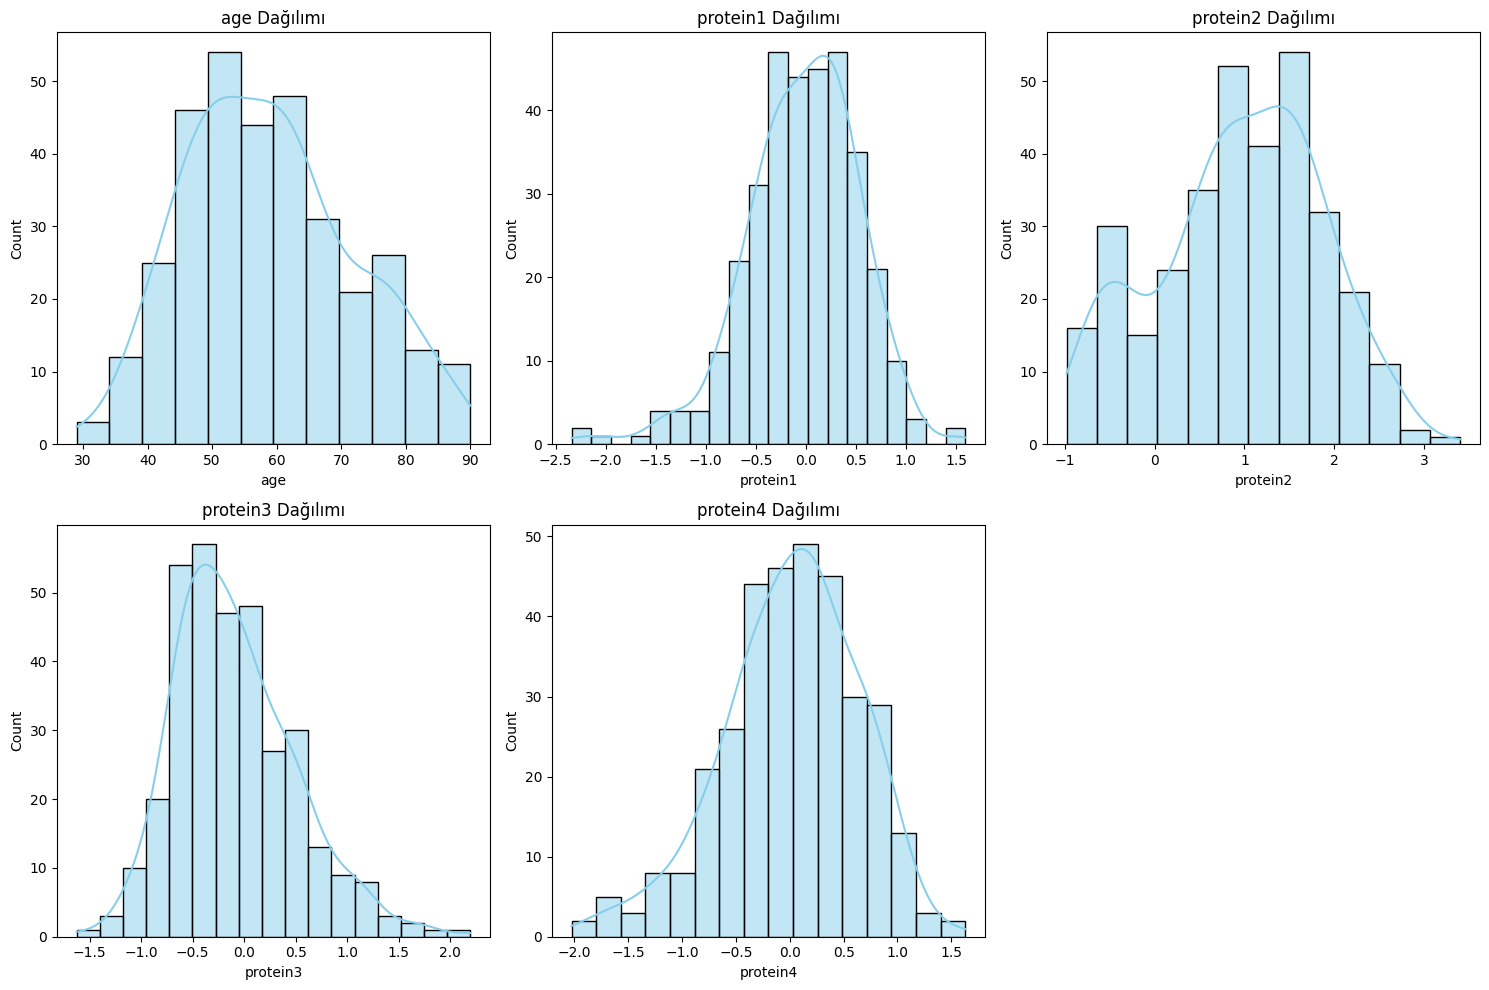

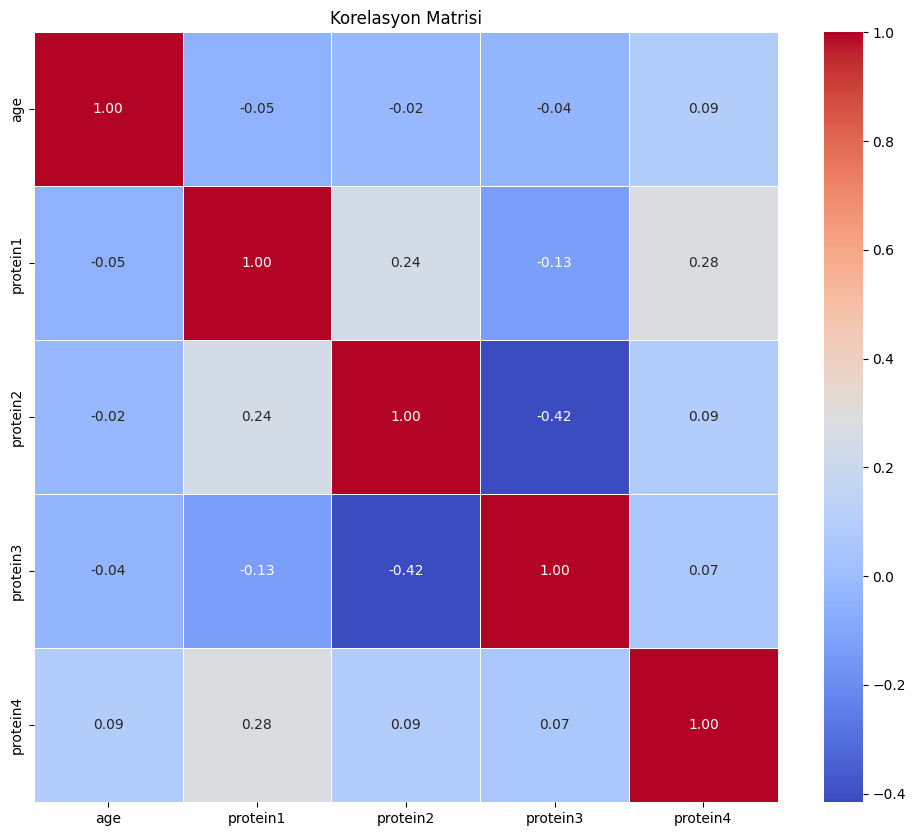

In [8]:
# Numerik Değişken Dağılımları
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:6]): # İlk 6
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'{col} Dağılımı')
plt.tight_layout()
plt.show()

# Korelasyon Matrisi
if len(num_cols) > 1:
    plt.figure(figsize=(12, 10))
    sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
    plt.title('Korelasyon Matrisi')
    plt.show()


## 🧹 4. Eksik Veri Yönetimi

,Eksik Sayısı,Eksik Oranı (%)
date_of_last_visit,24,7.038123
patient_status,20,5.865103
patient_id,7,2.052786
age,7,2.052786
protein2,7,2.052786
protein3,7,2.052786
gender,7,2.052786
protein1,7,2.052786
tumour_stage,7,2.052786
protein4,7,2.052786


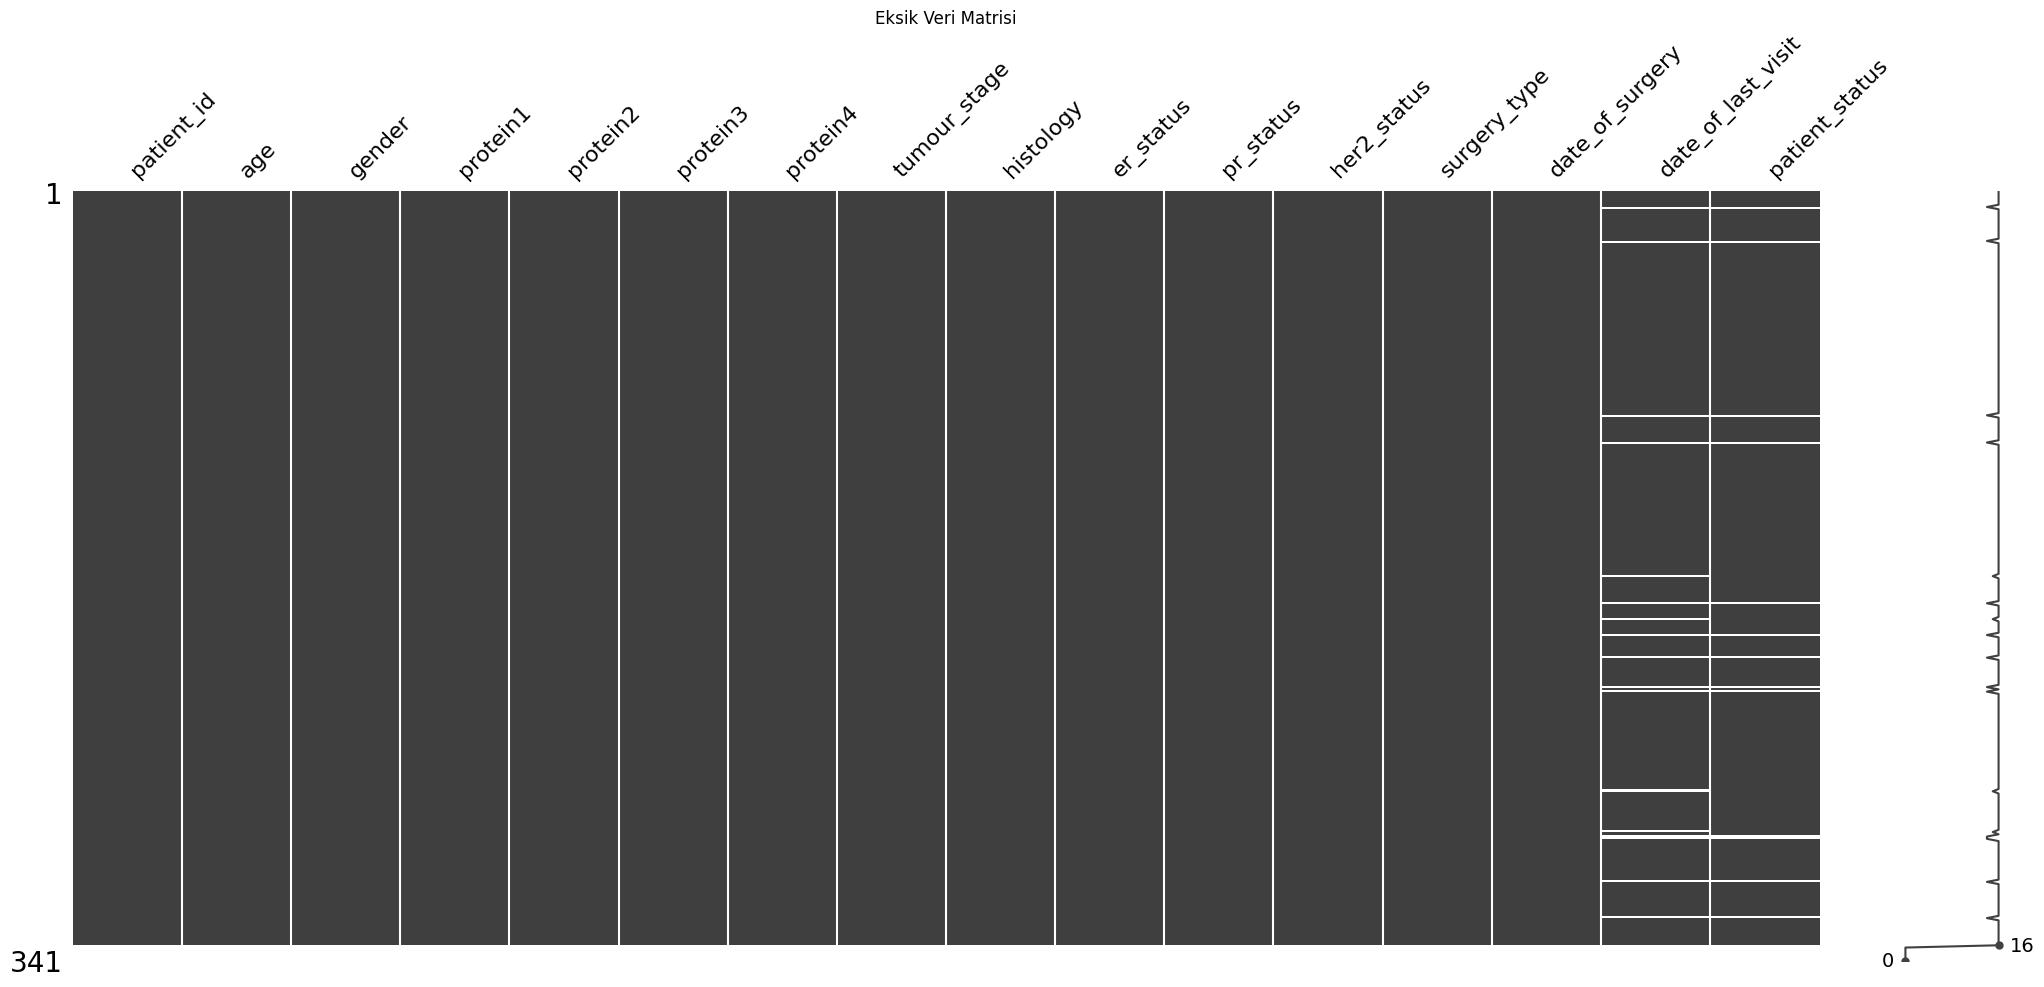

In [9]:
# Eksik Veri Analizi
missing_df = df.isnull().sum().to_frame(name='Eksik Sayısı')
missing_df['Eksik Oranı (%)'] = (missing_df['Eksik Sayısı'] / len(df)) * 100
missing_df = missing_df[missing_df['Eksik Sayısı'] > 0].sort_values(by='Eksik Sayısı', ascending=False)
display(missing_df)

if not missing_df.empty:
    msno.matrix(df)
    plt.title('Eksik Veri Matrisi')
    plt.show()
else:
    print("✅ Veri setinde eksik değer bulunmamaktadır.")

## 🔧 5. & 6. Veri Tipleri ve Feature Engineering

In [10]:
# ID Sütununu Kaldırma
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    print(f"ℹ️ ID Sütunu silindi: id")

df=df.drop('date_of_surgery',axis=1)
df=df.drop('date_of_last_visit',axis=1)
df=df.drop('patient_id',axis=1)

# Tarih Dönüşümü (Otomatik Tespit Denemesi)
for col in df.columns:
    if 'date' in col.lower() or 'time' in col.lower():
        try:
            df[col] = pd.to_datetime(df[col])
            df[f'{col}_year'] = df[col].dt.year
            df[f'{col}_month'] = df[col].dt.month
            df.drop(col, axis=1, inplace=True) # Orijinal tarihi kaldır (Regresyon için)
            print(f"✅ {col} datetime'a çevrildi ve parçalandı.")
        except: pass

print("Feature Engineering Tamamlandı.")

Feature Engineering Tamamlandı.


## 🎯 7. Outlier Analizi (%10 - %90 Yöntemi)

✅ Outlier'lar %10-%90 aralığına baskılandı.


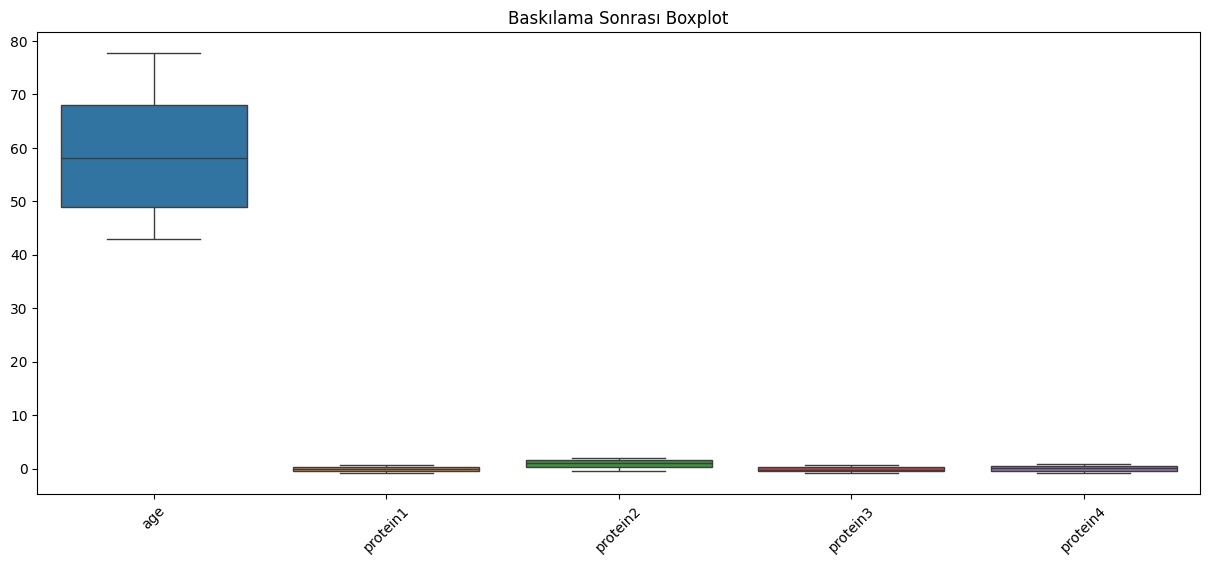

In [11]:
def clip_outliers(dataframe, cols):
    for col in cols:
        lower = dataframe[col].quantile(0.10)
        upper = dataframe[col].quantile(0.90)
        dataframe[col] = np.clip(dataframe[col], lower, upper)
    return dataframe

# Numerik sütunları güncelle (Target hariç)
target = 'patient_status'
feature_cols = [c for c in num_cols if c != target]

df = clip_outliers(df, feature_cols)
print("✅ Outlier'lar %10-%90 aralığına baskılandı.")

# Kontrol
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[feature_cols[:6]]) # İlk 6
plt.xticks(rotation=45)
plt.title('Baskılama Sonrası Boxplot')
plt.show()

In [12]:
df.head()

,age,gender,protein1,protein2,protein3,protein4,tumour_stage,histology,er_status,pr_status,her2_status,surgery_type,patient_status
0,43.0,FEMALE,0.080353,0.42638,0.54715,0.273680,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy,Alive
1,43.0,FEMALE,-0.420320,0.57807,0.61447,-0.031505,II,Mucinous Carcinoma,Positive,Positive,Negative,Lumpectomy,Dead
2,69.0,FEMALE,0.213980,1.31140,-0.32747,-0.234260,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,Alive
3,56.0,FEMALE,0.345090,-0.21147,-0.19304,0.124270,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy,Alive
4,56.0,FEMALE,0.221550,1.90680,0.52045,-0.311990,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,Dead


## 🔀 8. Veri Ayrıştırma (Train-Test Split)

In [13]:
df = df.dropna(subset=['patient_status'])

X = df.drop('patient_status', axis=1)
y = df['patient_status']

all_columns = X.select_dtypes(include=['object', 'category']).columns
lbl_enc_columns = [col for col in all_columns if df[col].nunique() <= 2]
one_hot_enc_columns = [col for col in all_columns if df[col].nunique() > 2]

if y.dtype == 'object':
    le = LabelEncoder()
    y=le.fit_transform(y)
    joblib.dump(le, 'models/label_encoder.pkl')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Split Tamam. Train: {X_train.shape}, Test: {X_test.shape}")

✅ Split Tamam. Train: (256, 12), Test: (65, 12)


In [14]:
display(X.head())

,age,gender,protein1,protein2,protein3,protein4,tumour_stage,histology,er_status,pr_status,her2_status,surgery_type
0,43.0,FEMALE,0.080353,0.42638,0.54715,0.273680,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy
1,43.0,FEMALE,-0.420320,0.57807,0.61447,-0.031505,II,Mucinous Carcinoma,Positive,Positive,Negative,Lumpectomy
2,69.0,FEMALE,0.213980,1.31140,-0.32747,-0.234260,III,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other
3,56.0,FEMALE,0.345090,-0.21147,-0.19304,0.124270,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Modified Radical Mastectomy
4,56.0,FEMALE,0.221550,1.90680,0.52045,-0.311990,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other


## ⚙️ 9. Pipeline ile Ön İşleme

In [15]:
# Sütun Grupları
num_features = X.select_dtypes(include=[np.number]).columns

# Transformerlar
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

one_hot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

label_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', one_hot_transformer, one_hot_enc_columns),
        ('bin', label_transformer, lbl_enc_columns),
    ]
)
print("✅ ColumnTransformer Hazır.")

✅ ColumnTransformer Hazır.


## 🏆 10-14. Model Oluşturma, Karşılaştırma ve Optimizasyon

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, clf in models.items():
    model = Pipeline([
        ('prep', preprocessor), # Senin hazırladığın ColumnTransformer
        ('clf', clf)
    ])
    
    # Eğitim
    model.fit(X_train, y_train)
    
    # Değerlendirme
    score = model.score(X_test, y_test)
    results[name] = score

    print(f"✅ {name} Tamamlandı. Accuracy: {score:.4f}")

print("-" * 30)

the_best_score=0
the_best_model=""
for name, score in results.items():
    if score> the_best_score:
        the_best_score = score
        the_best_model=name
    else:
        pass

print(f"Best Model {the_best_model}: {the_best_score:.4f}")

best_model = Pipeline([
        ('prep', preprocessor), # Senin hazırladığın ColumnTransformer
        ('clf', models[the_best_model])
    ])


✅ Logistic Regression Tamamlandı. Accuracy: 0.8000
✅ Random Forest Tamamlandı. Accuracy: 0.7846
✅ XGBoost Tamamlandı. Accuracy: 0.8154
------------------------------
Best Model XGBoost: 0.8154


In [17]:
# Classification Report
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.94      0.89        52
           1       0.57      0.31      0.40        13

    accuracy                           0.82        65
   macro avg       0.71      0.62      0.65        65
weighted avg       0.79      0.82      0.79        65



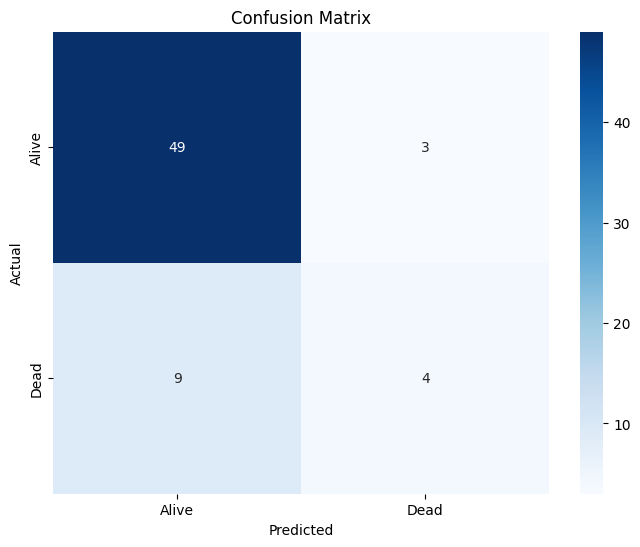

In [18]:
# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Alive', 'Dead'], yticklabels=['Alive', 'Dead'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

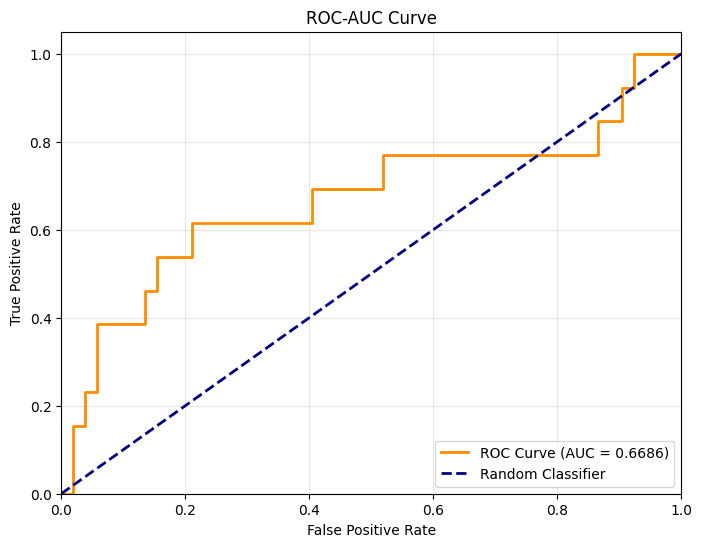

ROC-AUC Score: 0.6686


In [19]:
# ROC-AUC Curve
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities
if hasattr(best_model, 'predict_proba'):
    y_prob = best_model.predict_proba(X_test)[:, 1]
else:
    y_prob = best_model.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

## 🧠 15. Derin Öğrenme (Deep Learning)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5508 - loss: 0.6901 - val_accuracy: 0.8000 - val_loss: 0.6201
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7930 - loss: 0.5943 - val_accuracy: 0.8000 - val_loss: 0.5503
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7930 - loss: 0.5361 - val_accuracy: 0.8000 - val_loss: 0.5020
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7930 - loss: 0.5044 - val_accuracy: 0.8000 - val_loss: 0.4911
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7930 - loss: 0.5046 - val_accuracy: 0.8000 - val_loss: 0.4941
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7930 - loss: 0.4947 - val_accuracy: 0.8000 - val_loss: 0.4886
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7930 - loss: 0.4862 - val_accuracy: 0.8000 - val_loss: 0.4876
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7930 - loss: 0.4799 - val_accuracy: 0.8000 - val_loss:

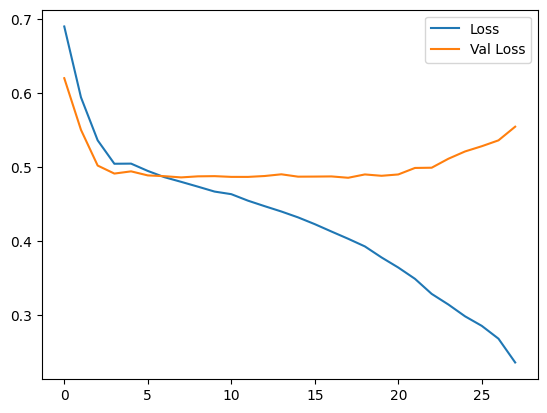

In [20]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Veri Hazırlığı (Pipeline'dan geçir)
X_train_dl = best_model.named_steps['prep'].transform(X_train)
X_test_dl = best_model.named_steps['prep'].transform(X_test)

if hasattr(X_train_dl, 'toarray'): 
    X_train_dl = X_train_dl.toarray(); 
    X_test_dl = X_test_dl.toarray()

# Model Mimarisi
dl_model=Sequential()
dl_model.add(Dense(120, activation='relu'))
dl_model.add(Dense(64, activation='relu'))
dl_model.add(Dense(30, activation='relu'))
dl_model.add(Dense(8, activation='relu'))
dl_model.add(Dense(1, activation='sigmoid'))


dl_model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = dl_model.fit(
        X_train_dl, y_train,
        validation_data=(X_test_dl, y_test),
        epochs=100, batch_size=32,
        callbacks=[early_stop],
        verbose=1)

plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); 
plt.show()

## 📊 ML vs DL Model Karşılaştırması

,ML (Best Model),DL (Neural Network)
Metric,,
Accuracy,0.8154,0.8000
Precision,0.7901,0.6400
Recall,0.8154,0.8000
F1-Score,0.7927,0.7111


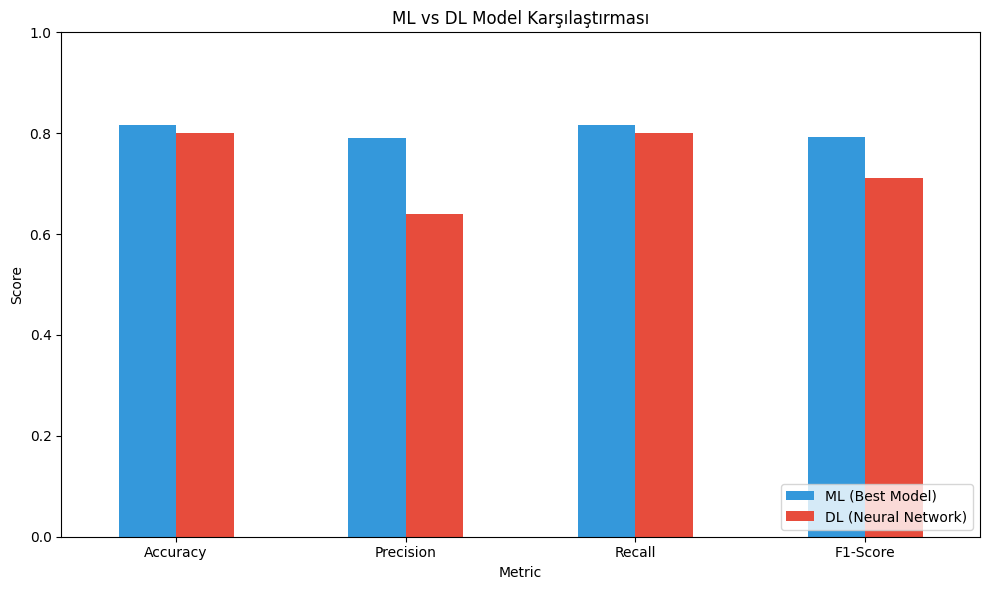


🏆 Sonuç: ML modeli F1-Score bazında daha iyi performans göstermiştir.


In [21]:
# ML vs DL Comparison
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ML Predictions
ml_pred = best_model.predict(X_test)
ml_acc = accuracy_score(y_test, ml_pred)
ml_prec = precision_score(y_test, ml_pred, average='weighted')
ml_rec = recall_score(y_test, ml_pred, average='weighted')
ml_f1 = f1_score(y_test, ml_pred, average='weighted')

# DL Predictions
dl_pred_prob = dl_model.predict(X_test_dl, verbose=0)
dl_pred = (dl_pred_prob > 0.5).astype(int).flatten()
dl_acc = accuracy_score(y_test, dl_pred)
dl_prec = precision_score(y_test, dl_pred, average='weighted')
dl_rec = recall_score(y_test, dl_pred, average='weighted')
dl_f1 = f1_score(y_test, dl_pred, average='weighted')

# Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'ML (Best Model)': [ml_acc, ml_prec, ml_rec, ml_f1],
    'DL (Neural Network)': [dl_acc, dl_prec, dl_rec, dl_f1]
})
comparison_df = comparison_df.set_index('Metric')
display(comparison_df.style.format("{:.4f}").highlight_max(axis=1, color='lightgreen'))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_title('ML vs DL Model Karşılaştırması')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

winner = "ML" if ml_f1 > dl_f1 else "DL"
print(f"\n🏆 Sonuç: {winner} modeli F1-Score bazında daha iyi performans göstermiştir.")

## 💾 16. Model Kaydetme

In [39]:
# ML Modeli
joblib.dump(best_model, 'models/best_model.pkl')

# DL Modeli
if 'dl_model' in locals():
 dl_model.save('models/dl_model.keras')

print("✅ Tüm modeller başarıyla kaydedildi.")

✅ Tüm modeller başarıyla kaydedildi.


## Sonuç ve Değerlendirme

| Model | Accuracy | Notlar |
|---|---|---|
| Logistic Regression | 0.8000 | Yorumlanabilir baseline |
| Random Forest | 0.7846 | Ensemble yöntemi |
| **XGBoost (En İyi)** | **0.8154** | Gradient boosting kazananı |
| Neural Network (DL) | Dense (120→64→30→8→1) | Binary cross-entropy, EarlyStopping (patience=10) |

**Bulgular:**
- XGBoost en yüksek doğruluğa (0.8154) ulaşarak en iyi ML modeli olmuştur
- Sınıf dengesizliği (%80 Alive / %20 Dead) nedeniyle `Dead` sınıfı tespitinde düşük recall (0.31) gözlemlenmiştir
- Confusion matrix ve ROC-AUC eğrisi ile model performansı görselleştirilmiştir
- %10–%90 aralığına baskılama ile aykırı değerlerin etkisi azaltılmıştır
- SMOTE veya `class_weight` parametresi ile azınlık sınıf (Dead) recall değeri artırılabilir